In [1]:
from tensor_contraction import TensorNetwork, TensorNetworkOptimizer, State
import numpy as np

In [2]:
def generate_lambda(probability, n):
    '''
    Generate matrix lambd[i,j]
    lambd[i,j] == 1 => RZZ will act on i-th and j-th qubit
    '''
    lambd = np.zeros((n, n))
    for i in range(n):
        for j in range(i):
            if np.random.rand() < probability:
                lambd[i, j] = 1
    return lambd


def generate_lambda_nearest(n):
    '''
    Generate coupling matrix with nearest neighbor interaction
    '''
    lambd = np.zeros((n, n))
    for i in range(n):
        lambd[(i+1) % n, i] = 1
    return lambd

In [3]:
n_layers = 2
prob = .1
n_qubits = 4

gammas = np.random.uniform(0, 2*np.pi, size=n_layers)
betas = np.random.uniform(0, 2*np.pi, size=n_layers)
lambd = np.array([[0,0, 0, 0],
        [1, 0, 0, 0],
        [1, 0, 0, 0],
        [1, 1, 0, 0]])

lambd = np.array([
                [0, 0, 0, 0],
                [1, 0, 0, 0],
                [0, 0, 0, 0],
                [0, 1, 1, 0]
                ])


In [4]:
net = TensorNetwork.qaoa_like_from_params(lambd, gammas, betas, generate_meas_layer=True)

In [5]:
lambd

array([[0, 0, 0, 0],
       [1, 0, 0, 0],
       [0, 0, 0, 0],
       [0, 1, 1, 0]])

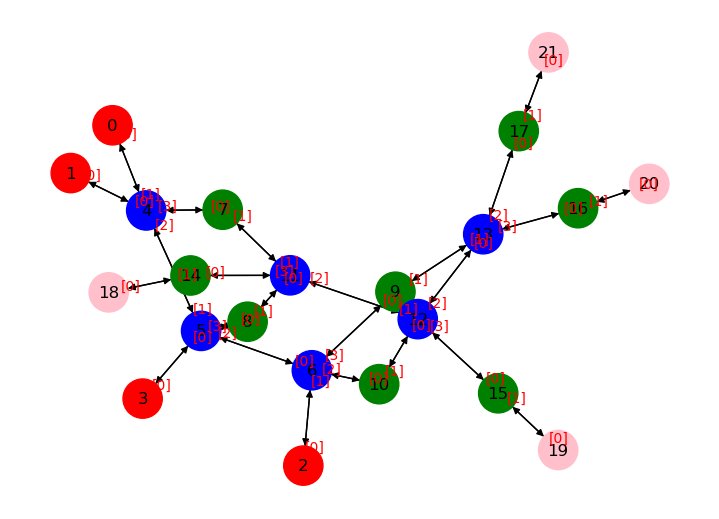

In [6]:
'''
Red - input state
Green - rx
Blue - rzz
'''
net.draw_network()

In [10]:
opt = TensorNetworkOptimizer(net)
seq, cost = opt.optimize_network(k=4)
print(seq)
print(cost)

KeyboardInterrupt: 

In [ ]:
sum = 0
np.set_printoptions(precision=2)
for (i,j) in seq:
    cost = net.merge_nodes(i,j, actually_contract=True)
    sum+=cost
    print(i,j)
    print(cost)

In [ ]:
net.draw_network()

In [ ]:
'''
run qaoa gate by gate
'''
s = State(n_qubits)
s.run_qaoa(lambd, gammas, betas)
s.state

In [ ]:
'''
Verify result is the same
'''
np.allclose(s.state, net.nodes[0].tensor)

In [ ]:
net.nodes[0].tensor